# Static models for NOAA data

Dataset: Weekly mean sea-surface temperature as given by the NOAA Optimum Interpolation SST V2 dataset [[1]](https://psl.noaa.gov/data/gridded/data.noaa.oisst.v2.html)

Models: Static SHRED & SDN from [[2]](https://royalsocietypublishing.org/rspa/article/480/2298/20240054/66770/Sensing-with-shallow-recurrent-decoder) [[3]](https://github.com/Jan-Williams/pyshred/tree/main)

In [13]:
# Standard imports
import json
import os
import random

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import MinMaxScaler

# Local imports
import models  # https://github.com/Jan-Williams/pyshred/blob/main/models.py
from helper_functions.noaa_data import crop_to_area, load_data
from helper_functions.plotting_functions import plot_sst_map
from helper_functions.preprocess_SDN import create_sdn_datasets
from helper_functions.preprocess_SHRED import (
    convert_to_anomaly,
    create_shred_sequences,
    split_ordered_data,
)
from helper_functions.saving import JsonEncoder

np.random.seed(42)
random.seed(42)

## Set up

In [14]:
exp_name = "NOAA/NA/SHRED-GRU"
model_type = "SHRED"
num_sensors = 3
lags = 52
hidden_dim = 64
sequence_model = "GRU"
anomaly = False
area = "NA"

## Load data
From Mobile-Sensor SHRED paper [[4]](https://ieeexplore.ieee.org/document/10584544):

- Weekly mean SST from 1992 - 2019
- 1400 snapshots of a 180 x 360 grid, with landmass excluded leaves 44,219 spatial locations corresponding to the sea surface

In [15]:
data, lats, longs, dates = load_data()
print(data.shape, len(longs), len(lats))

(1400, 44219) 44219 44219


In [16]:
if area != "world":
    data, lats, longs = crop_to_area(data, lats, longs, area=area)
    print(data.shape, len(longs), len(lats))

(1400, 3805) 3805 3805


In [17]:
# sensor_locs = range(0, data.shape[1], int(data.shape[1]/10))
# data_in = np.zeros((len(data), len(sensor_locs)))
# for i in range(len(data_in)):
#     data_in[i] = data[i, sensor_locs]
# plt.plot(data_in)
# plt.show()

## SHRED preprocessing

In [18]:
print("Preprocessing data...")
train_data, val_data, test_data, train_dates, val_dates, test_dates = split_ordered_data(data, dates, all_dates=True)
if anomaly:
    train_anomaly, val_anomaly, test_anomaly, bulk_mean = convert_to_anomaly((train_data, val_data, test_data))

Preprocessing data...


In [19]:
print(train_data.shape)
print(val_data.shape)
print(test_data.shape)
print(len(train_data)+len(test_data)+len(val_data))

(1050, 3805)
(175, 3805)
(175, 3805)
1400


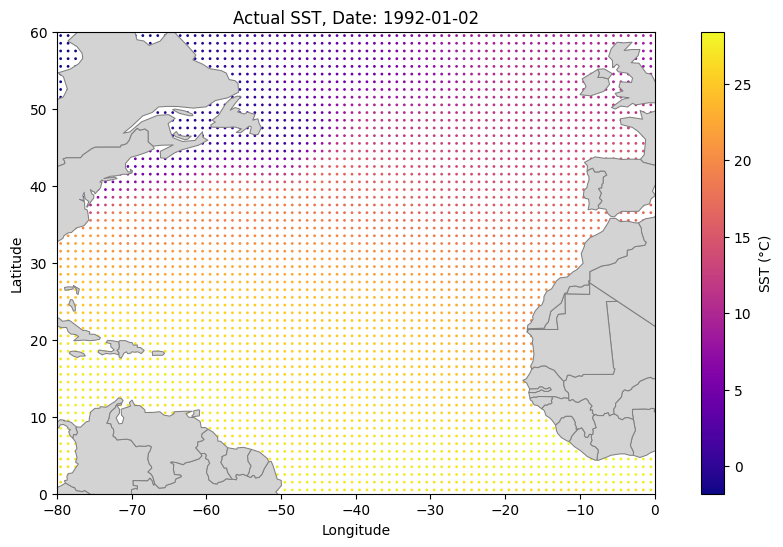

In [20]:
# Plots for santity checks:
plot_index = 0
sst_df = pd.DataFrame({
    "Longitude": longs,
    "Latitude": lats,
    "SST": train_data[plot_index]
})
plot_sst_map(sst_df, cmap="plasma", title=f"Actual SST, Date: {train_dates[plot_index]}", area=area)

if anomaly:
    anomaly_df = pd.DataFrame({
        "Longitude": longs,
        "Latitude": lats,
        "SST": train_anomaly[plot_index]
    })
    plot_sst_map(anomaly_df, cmap="viridis", title=f"SST Anomaly, Date: {train_dates[plot_index]}", area=area)

    bulk_df = pd.DataFrame({
        "Longitude": longs,
        "Latitude": lats,
        "SST": bulk_mean
    })
    plot_sst_map(bulk_df, cmap="plasma", title=f"Bulk mean SST, Dates: {train_dates[0]} to {train_dates[-1]}", area=area)

In [21]:
# Normalise data
if anomaly:
    sc = MinMaxScaler()
    sc = sc.fit(train_anomaly)  # Computes min and max from training data only (prevent data leakage)
    train_transformed = sc.transform(train_anomaly)  
    val_transformed = sc.transform(val_anomaly)
    test_transformed = sc.transform(test_anomaly)
else:
    sc = MinMaxScaler()
    sc = sc.fit(train_data)  # Computes min and max from training data only (prevent data leakage)
    train_transformed = sc.transform(train_data)  
    val_transformed = sc.transform(val_data)
    test_transformed = sc.transform(test_data)

# Build sequences
sensor_locations = np.random.choice(data.shape[1], size=num_sensors, replace=False)
sensor_coords=(longs[sensor_locations], lats[sensor_locations])
print(f"Sensor location indexes will be: {sensor_locations}")

# Build sequences
if model_type == "SHRED":
    train_dataset = create_shred_sequences(train_transformed, sensor_locations, lags=lags)
    val_dataset = create_shred_sequences(val_transformed, sensor_locations, lags=lags)
    test_dataset = create_shred_sequences(test_transformed, sensor_locations, lags=lags)

    # Get dates corresponding to the predictions made by the model
    train_lag_dates = train_dates[np.array(range(len(train_dates)-lags)) + lags - 1]
    val_lag_dates = val_dates[np.array(range(len(val_dates)-lags)) + lags - 1]
    test_lag_dates = test_dates[np.array(range(len(test_dates)-lags)) + lags - 1]

elif model_type == "SDN":
    train_dataset = create_sdn_datasets(train_transformed, sensor_locations)
    val_dataset = create_sdn_datasets(val_transformed, sensor_locations)
    test_dataset = create_sdn_datasets(test_transformed, sensor_locations)

    # Generate test set to match SHRED test set
    # (use final sensor results for what each sequence would be if using SHRED)
    test_dataset_match_shred = create_sdn_datasets(test_transformed, sensor_locations, test_lags=lags)
    test_lag_dates = test_dates[np.array(range(len(test_dates)-lags)) + lags - 1]

Sensor location indexes will be: [2014  527  478]


In [ ]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))
print(len(train_dataset) + len(val_dataset) + len(test_dataset))

In [ ]:
if model_type == "SHRED":
    plot_index = 3
    plot_data = test_dataset[plot_index]
    random_colours = ["#"+''.join([random.choice('0123456789ABCDEF') for j in range(6)])
                for i in range(num_sensors)]

    for i in range(num_sensors):
        # plot_data[0] -> test sequences
        # plot_data[0].T -> for each sensor, timeseries of SST values across test dataset
        plt.plot(plot_data[0].T[i], c=random_colours[i])
    plt.ylabel("SST")
    plt.xlabel("Week index")
    plt.grid()
    plt.xlim(0, 52)
    plt.show()

## Train + test SHRED model

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

if model_type == "SHRED":
    model = models.SHRED(num_sensors, len(lats), seq_model=sequence_model, hidden_size=hidden_dim,
                        hidden_layers=2, l1=350, l2=400, dropout=0.1).to(device)
elif model_type == "SDN":
    model = models.SDN(num_sensors, len(lats), l1=350, l2=400, dropout=0.1).to(device)

validation_errors = models.fit(model, train_dataset, val_dataset, batch_size=64, num_epochs=1000, lr=1e-3, verbose=True, patience=5)

In [ ]:
test_recons = sc.inverse_transform(model(test_dataset.X).detach().cpu().numpy())
test_ground_truth = sc.inverse_transform(test_dataset.Y.detach().cpu().numpy())
print('Test Reconstruction Error: ')
print(np.linalg.norm(test_recons - test_ground_truth) / np.linalg.norm(test_ground_truth))

if model_type == "SDN":
    test_recon_lags = sc.inverse_transform(model(test_dataset_match_shred.X).detach().cpu().numpy())
    ground_truth_lags = sc.inverse_transform(test_dataset_match_shred.Y.detach().cpu().numpy())
    print('Test (matching SHRED lags) Reconstruction Error: ')
    print(np.linalg.norm(test_recon_lags - ground_truth_lags)/ np.linalg.norm(ground_truth_lags))

## Save results

In [ ]:
# Make experiment folder
directory = f"Reconstructions/Static/{exp_name}/"
os.makedirs(directory, exist_ok = True)

In [ ]:
if model_type == "SHRED":
    np.save(f"Reconstructions/Static/{exp_name}/recons_n{num_sensors}_l{lags}", test_recons)
    np.save(f"Reconstructions/Static/{exp_name}/truth_n{num_sensors}_l{lags}", test_ground_truth)

elif model_type == "SDN":
    np.save(f"Reconstructions/Static/{exp_name}/recons_n{num_sensors}", test_recons)
    np.save(f"Reconstructions/Static/{exp_name}/truth_n{num_sensors}", test_ground_truth)
    np.save(f"Reconstructions/Static/{exp_name}/recons_n{num_sensors}_l{lags}", test_recon_lags)
    np.save(f"Reconstructions/Static/{exp_name}/truth_n{num_sensors}_l{lags}", ground_truth_lags)

In [ ]:
metadata = {
    "sensor_locations": list(sensor_locations),
    "sensor_coords": list(sensor_coords)
    }

if anomaly:
    metadata["bulk_mean"] = bulk_mean

In [ ]:
if model_type == "SHRED":
    metadata["test_lag_dates"] = test_lag_dates
    with open(f"Reconstructions/Static/{exp_name}/metadata_n{num_sensors}_l{lags}.json", 'w', encoding='utf-8') as f:
        json.dump(metadata, f, cls=JsonEncoder)

elif model_type == "SDN":
    with open(f"Reconstructions/Static/{exp_name}/metadata_n{num_sensors}.json", 'w', encoding='utf-8') as f:
        json.dump(metadata, f, cls=JsonEncoder)

    metadata["test_lag_dates"] = test_lag_dates
    with open(f"Reconstructions/Static/{exp_name}/metadata_n{num_sensors}_l{lags}.json", 'w', encoding='utf-8') as f:
        json.dump(metadata, f, cls=JsonEncoder)